In [1]:
import numpy as np
import pandas as pd
from io import StringIO

def compute_individual_weights(df, population_proportions):
    """Computes individual weights using a weighted sum approach and calculates an adjustment index."""
    
    # Compute the sum of occurrences for each category in the sample
    category_totals = df.sum(axis=0)  # Sum across individuals
    
    # Compute weights for each individual
    weights = df.apply(lambda row: sum(row[col] * (population_proportions[col] / category_totals[col]) 
                                       for col in df.columns if category_totals[col] > 0), axis=1)

    # Normalize weights to keep total sum of weights = number of individuals
    weights *= len(df) / weights.sum()

    # Compute the adjustment index
    adjustment_index = 1 - np.mean(np.abs(weights - 1))

    return dict(zip(df.index, weights)), adjustment_index

# Example data
csv_data = """
individual,A,B,C,D,E
a,1,0,1,0,1
b,0,1,0,1,0
c,1,0,1,0,0
d,0,1,0,1,0
"""

df = pd.read_csv(StringIO(csv_data), index_col=0)

population_proportions = {'A': 0.0, 'B': 1, 'C': 0.5, 'D': .5, 'E': 1}

weights, adjustment_index = compute_individual_weights(df, population_proportions)

print("Weights:", weights)
print("Adjustment Index:", adjustment_index)


Weights: {'a': 1.6666666666666665, 'b': 1.0, 'c': 0.3333333333333333, 'd': 1.0}
Adjustment Index: 0.6666666666666667


# Aplicação

In [5]:
df_parls_raw = pd.read_csv(r'../../data/df_parl_detalhes.csv', index_col=0)

In [6]:
df_parls = df_parls_raw.copy()

df_parls = df_parls.join(pd.get_dummies(df_parls['sexo']))

df_parls.set_index('id', inplace=True)

In [7]:
population_proportions = {'F': 0.5, 'M': 0.5}


results = []
df_index = pd.DataFrame()
for legislatura in sorted(df_parls['ultimoStatus.idLegislatura'].unique()):
    df_parls_leg = df_parls[df_parls['ultimoStatus.idLegislatura'] == legislatura]
    weights, adjustment_index = compute_individual_weights(df_parls_leg[['F', 'M']], population_proportions)
    df_index = pd.concat([df_index, pd.DataFrame({
        'parl_id': weights.keys(),
        'legislatura': legislatura,
        'weights': weights.values(),
    })])

    # print("Weights:", weights)
    print("Adjustment Index:", adjustment_index)
    results.append({
        'legislatura': legislatura,
        'adjustment_index': adjustment_index
    })






Adjustment Index: 0.09771986970684043
Adjustment Index: 0.0547945205479452
Adjustment Index: 0.177966101694915
Adjustment Index: 0.11428571428571455
Adjustment Index: 0.19531249999999978
Adjustment Index: 0.16988416988416977
Adjustment Index: 0.20915032679738554
Adjustment Index: 0.19753086419753085
Adjustment Index: 0.35254237288135604
Adjustment Index: 0.3615257048092869


In [ ]:
df_index.to_csv('../../outputs/df_equality_index.csv', index=False)


OSError: Cannot save file into a non-existent directory: '..\outputs'

<Axes: xlabel='legislatura'>

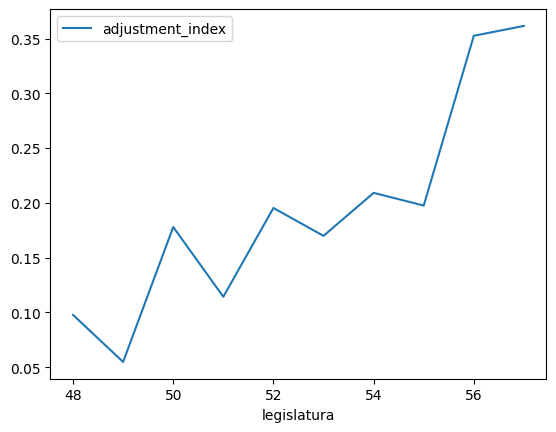

In [ ]:
pd.DataFrame(results).plot(x='legislatura', y='adjustment_index', kind='line')


,parl_id,legislatura,weights
0,139265,48,0.525685
1,139269,48,0.525685
2,139268,48,0.525685
3,139266,48,0.525685
4,139267,48,0.525685
...,...,...,...
302,139248,48,0.525685
303,139252,48,0.525685
304,139251,48,0.525685
305,139254,48,0.525685
